# Brain Drain: Skilled Worker Emigration from Africa to the USA
### Exploratory analysis of World Bank migration, remittance and labour-market indicators

Every year thousands of African doctors, nurses, engineers and software developers leave for the
United States, the UK, Canada and the Gulf. The US alone is home to over two million African-born
immigrants, one of the most highly educated immigrant groups in the country. This notebook uses
**real World Bank World Development Indicators** for 15 major source countries to quantify the
*push* (unemployment, low income), the *outflow* (net migration) and the *return flow*
(remittances) of African brain drain.

**Data (data/raw/, from api.worldbank.org/v2):**

| File | Indicator | Code |
|---|---|---|
| wb_net_migration.json | Net migration (people) | SM.POP.NETM |
| wb_remittances_usd.json | Personal remittances received (US$) | BX.TRF.PWKR.CD.DT |
| wb_remittances_pct_gdp.json | Personal remittances (% of GDP) | BX.TRF.PWKR.DT.GD.ZS |
| wb_gdp_per_capita.json | GDP per capita (current US$) | NY.GDP.PCAP.CD |
| wb_unemployment.json | Unemployment (% of labour force) | SL.UEM.TOTL.ZS |
| wb_tertiary_enrollment.json | Tertiary enrollment (% gross) | SE.TER.ENRR |
| wb_migrant_stock.json | International migrant stock | SM.POP.TOTL |
| wb_population.json | Population, total | SP.POP.TOTL |

> **Caveat:** World Bank net migration counts *all* migrants (all skill levels, all destinations),
> so it is a proxy for brain drain rather than a direct count of skilled emigrants to the USA.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Works whether the notebook is launched from notebooks/ or the project root.
RAW_DIR = Path("../data/raw") if Path("../data/raw").exists() else Path("data/raw")

FILES = {
    "net_migration": "wb_net_migration.json",
    "remittances_usd": "wb_remittances_usd.json",
    "remittances_pct_gdp": "wb_remittances_pct_gdp.json",
    "gdp_per_capita": "wb_gdp_per_capita.json",
    "unemployment": "wb_unemployment.json",
    "tertiary_enrollment": "wb_tertiary_enrollment.json",
    "migrant_stock": "wb_migrant_stock.json",
    "population": "wb_population.json",
}
REGIONS = {
    "NG": "West Africa", "GH": "West Africa", "SN": "West Africa", "CI": "West Africa",
    "CM": "Central Africa", "KE": "East Africa", "ET": "East Africa", "TZ": "East Africa",
    "UG": "East Africa", "EG": "North Africa", "MA": "North Africa", "ZA": "Southern Africa",
    "ZW": "Southern Africa", "ZM": "Southern Africa", "MW": "Southern Africa",
}
print("Reading raw World Bank files from", RAW_DIR.resolve())

Reading raw World Bank files from /home/ubuntu/github_repos/Data-Analytic-Data-Engineering/2026-10-07_immigration_africa_usa_brain_drain/data/raw


## 1. Load and parse the raw World Bank JSON responses

In [2]:
def parse_wb(path: Path, name: str) -> pd.DataFrame:
    meta, records = json.loads(path.read_text(encoding="utf-8"))
    df = pd.DataFrame({
        "country_code": [r["country"]["id"] for r in records],
        "country": [r["country"]["value"] for r in records],
        "year": [int(r["date"]) for r in records],
        "indicator": name,
        "value": [r["value"] for r in records],
    })
    print(f"{name:<22} {len(df):>4} rows | last updated {meta.get('lastupdated')} "
          f"| nulls {df['value'].isna().sum()}")
    return df

long_df = pd.concat([parse_wb(RAW_DIR / f, n) for n, f in FILES.items()], ignore_index=True)
long_df["country"] = long_df["country"].replace({"Egypt, Arab Rep.": "Egypt"})
long_df = long_df.dropna(subset=["value"])
long_df.head()

net_migration           150 rows | last updated 2026-07-13 | nulls 0
remittances_usd         150 rows | last updated 2026-07-13 | nulls 11
remittances_pct_gdp     150 rows | last updated 2026-07-13 | nulls 11
gdp_per_capita          150 rows | last updated 2026-07-13 | nulls 0
unemployment            150 rows | last updated 2026-07-13 | nulls 0
tertiary_enrollment     150 rows | last updated 2026-07-13 | nulls 69
migrant_stock            75 rows | last updated 2026-07-13 | nulls 0
population               75 rows | last updated 2026-07-13 | nulls 0


,country_code,country,year,indicator,value
0,CI,Cote d'Ivoire,2025,net_migration,"11,305.00"
1,CI,Cote d'Ivoire,2024,net_migration,"7,838.00"
2,CI,Cote d'Ivoire,2023,net_migration,"6,002.00"
3,CI,Cote d'Ivoire,2022,net_migration,"26,777.00"
4,CI,Cote d'Ivoire,2021,net_migration,"1,322.00"


In [3]:
wide = (long_df.pivot_table(index=["country_code", "country", "year"], columns="indicator",
                            values="value")
        .reset_index().sort_values(["country_code", "year"]))
wide.columns.name = None
wide["region"] = wide["country_code"].map(REGIONS)
wide["population_filled"] = wide.groupby("country_code")["population"].transform(
    lambda s: s.bfill().ffill())
wide["net_migration_per_1000"] = wide["net_migration"] / wide["population_filled"] * 1000
wide["remittances_bn"] = wide["remittances_usd"] / 1e9
panel = wide[wide["year"] >= 2016].copy()
print(panel.shape, "country-year rows (2016-2025)")
panel.describe().T[["count", "mean", "min", "max"]]

(150, 15) country-year rows (2016-2025)


,count,mean,min,max
year,150.00,"2,020.50","2,016.00","2,025.00"
gdp_per_capita,150.00,"2,165.88",450.51,"6,914.18"
migrant_stock,30.00,"961,182.40","102,358.00","2,880,839.00"
net_migration,150.00,"1,073.83","-879,235.00","458,246.00"
population,75.00,"60,832,065.63","15,797,210.00","237,527,782.00"
remittances_pct_gdp,139.00,3.60,0.18,11.37
remittances_usd,139.00,"5,275,519,403.79","38,464,441.00","41,517,400,000.00"
tertiary_enrollment,81.00,18.76,1.69,48.18
unemployment,150.00,6.48,1.56,34.01
population_filled,150.00,"59,542,217.35","15,797,210.00","237,527,782.00"


## 2. Who is losing the most people? Cumulative net migration 2016-2025

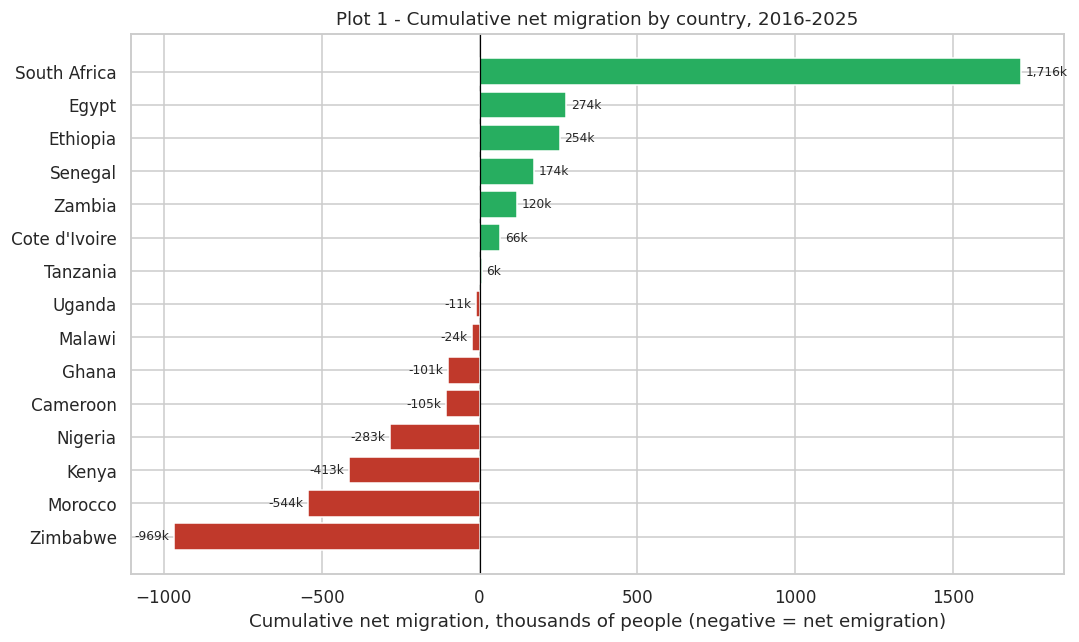

,country,region,net_migration
14,Zimbabwe,Southern Africa,"-968,641.00"
7,Morocco,North Africa,"-543,826.00"
5,Kenya,East Africa,"-412,595.00"
8,Nigeria,West Africa,"-283,025.00"
0,Cameroon,Central Africa,"-104,739.00"
4,Ghana,West Africa,"-100,885.00"
6,Malawi,Southern Africa,"-24,115.00"
12,Uganda,East Africa,"-10,887.00"
11,Tanzania,East Africa,"6,459.00"
1,Cote d'Ivoire,West Africa,"66,064.00"


In [4]:
cum = (panel.groupby(["country", "region"])["net_migration"].sum()
       .reset_index().sort_values("net_migration"))
colors = ["#c0392b" if v < 0 else "#27ae60" for v in cum["net_migration"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(cum["country"], cum["net_migration"] / 1e3, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Cumulative net migration, thousands of people (negative = net emigration)")
ax.set_title("Plot 1 - Cumulative net migration by country, 2016-2025")
for y, v in enumerate(cum["net_migration"] / 1e3):
    ax.text(v + (15 if v >= 0 else -15), y, f"{v:,.0f}k", va="center",
            ha="left" if v >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.show()
cum

**Insight:** Zimbabwe (about -969k), Morocco (-544k), Kenya (-413k) and Nigeria (-283k) recorded the
largest net outflows of the decade. Zimbabwe's exodus of nurses and doctors and Nigeria's "japa"
wave of tech and health professionals are well documented. South Africa is the
outlier: it *gains* people on net (+1.7M) because it is itself a destination for migrants from the
region, even while it loses its own skilled professionals to the UK, Australia and the USA.

## 3. Net migration trends for the largest source countries

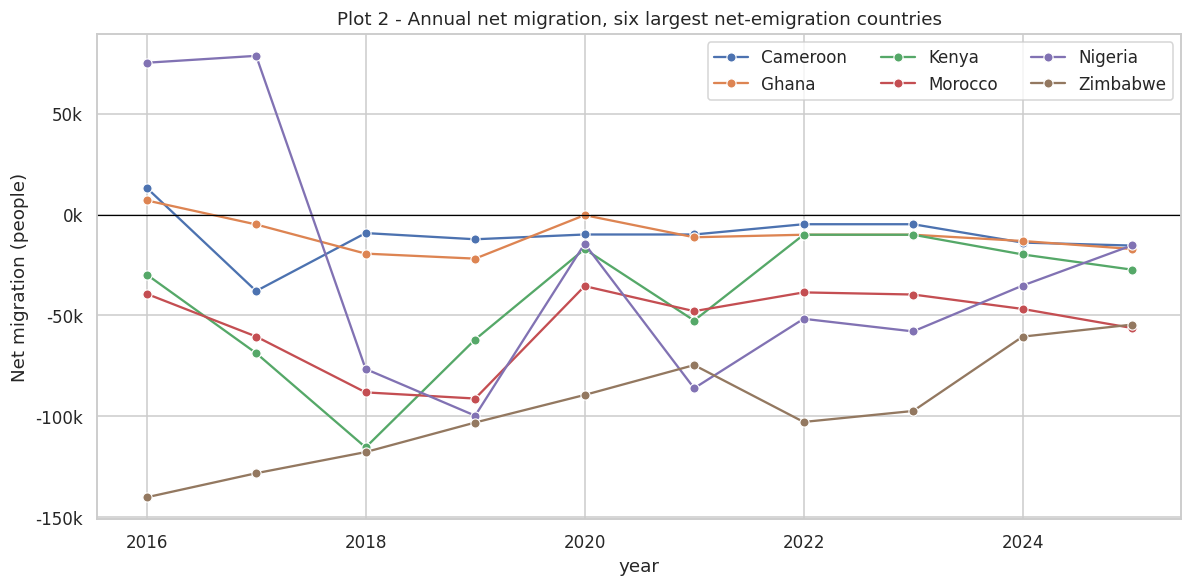

In [5]:
top_out = cum.nsmallest(6, "net_migration")["country"].tolist()
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.lineplot(data=panel[panel["country"].isin(top_out)], x="year", y="net_migration",
             hue="country", marker="o", ax=ax)
ax.axhline(0, color="black", lw=0.8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e3:,.0f}k"))
ax.set_title("Plot 2 - Annual net migration, six largest net-emigration countries")
ax.set_ylabel("Net migration (people)")
ax.legend(title="", ncol=3)
plt.tight_layout()
plt.show()

## 4. Remittances: the money that flows back

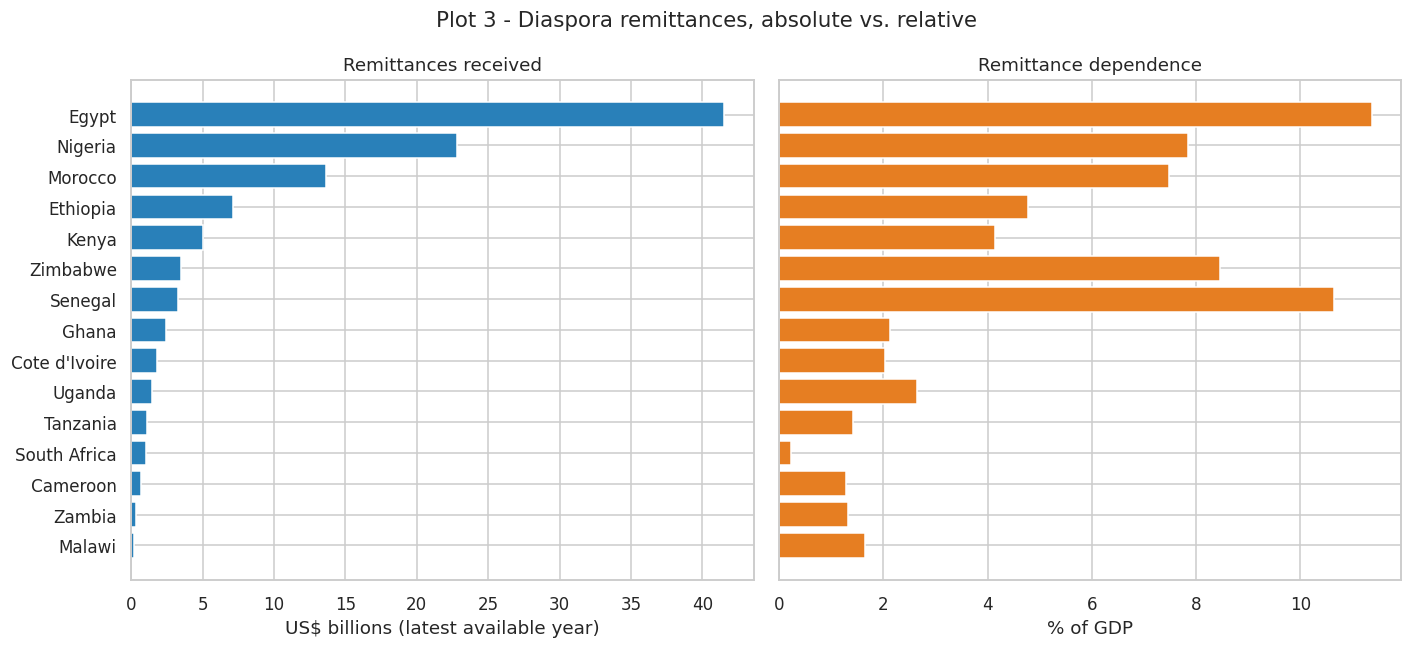

,country,year,remittances_bn,remittances_pct_gdp
102,Malawi,2024,0.19,1.65
180,Zambia,2024,0.33,1.32
24,Cameroon,2024,0.69,1.29
168,South Africa,2025,1.00,0.24
141,Tanzania,2024,1.12,1.42
154,Uganda,2024,1.43,2.65
11,Cote d'Ivoire,2024,1.77,2.03
64,Ghana,2025,2.42,2.12
127,Senegal,2023,3.27,10.64
193,Zimbabwe,2024,3.51,8.45


In [6]:
latest_rem = (panel.dropna(subset=["remittances_usd"]).sort_values("year")
              .groupby("country").tail(1).sort_values("remittances_usd", ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
axes[0].barh(latest_rem["country"], latest_rem["remittances_bn"], color="#2980b9")
axes[0].set_xlabel("US$ billions (latest available year)")
axes[0].set_title("Remittances received")
axes[1].barh(latest_rem["country"], latest_rem["remittances_pct_gdp"], color="#e67e22")
axes[1].set_xlabel("% of GDP")
axes[1].set_title("Remittance dependence")
fig.suptitle("Plot 3 - Diaspora remittances, absolute vs. relative", fontsize=14)
plt.tight_layout()
plt.show()
latest_rem[["country", "year", "remittances_bn", "remittances_pct_gdp"]]

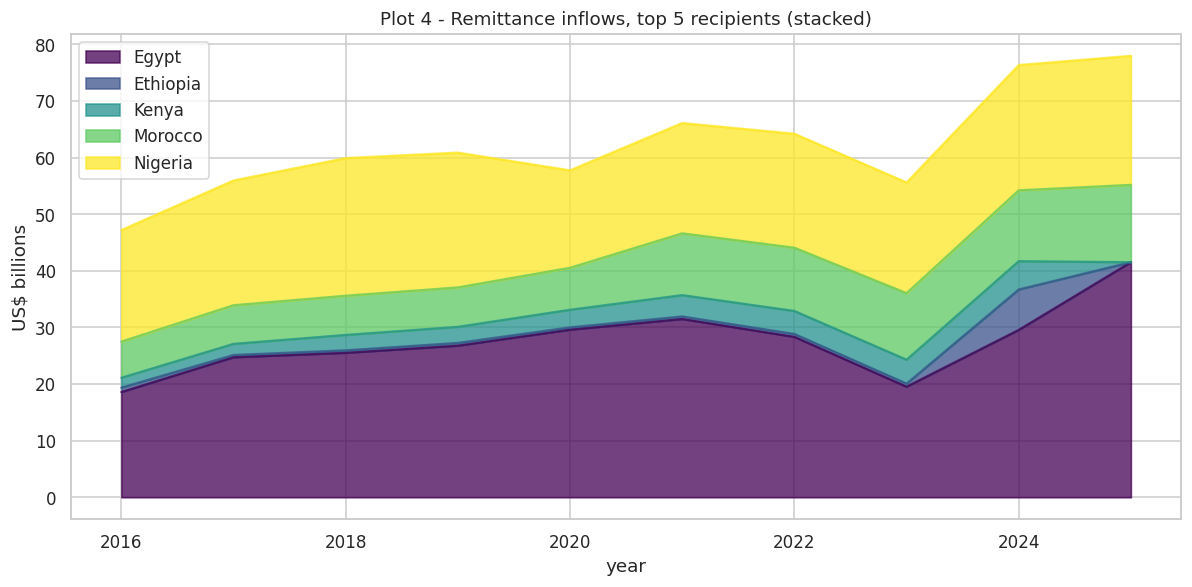

Total remittances, all 15 countries (US$ bn):
year
2016   57.00
2017   66.61
2018   70.91
2019   72.68
2020   69.70
2021   77.79
2022   77.26
2023   70.70
2024   89.26
2025   81.39


In [7]:
total = panel.groupby("year")["remittances_bn"].sum()
top5 = latest_rem.nlargest(5, "remittances_usd")["country"].tolist()
trend = panel[panel["country"].isin(top5)].pivot(index="year", columns="country",
                                                 values="remittances_bn")

fig, ax = plt.subplots(figsize=(11, 5.5))
trend.plot.area(ax=ax, alpha=0.75, colormap="viridis")
ax.set_ylabel("US$ billions")
ax.set_title("Plot 4 - Remittance inflows, top 5 recipients (stacked)")
ax.legend(title="", loc="upper left")
plt.tight_layout()
plt.show()
print("Total remittances, all 15 countries (US$ bn):")
print(total.round(2).to_string())

**Insight:** Remittances to the 15 countries rose from about **US$57bn in 2016 to US$89bn in 2024**.
Egypt (US$41.5bn in 2025) and Nigeria (US$22.8bn) dominate in absolute terms, and the USA is one
of the largest sending corridors for both. Relative to GDP, Egypt, Senegal and Zimbabwe are the most
dependent on diaspora income (8-11% of GDP), so the emigrants who left still prop up household
consumption and foreign-exchange reserves back home. (2025 totals are partial because several
countries have not reported yet.)

## 5. Push factors: income gap and unemployment

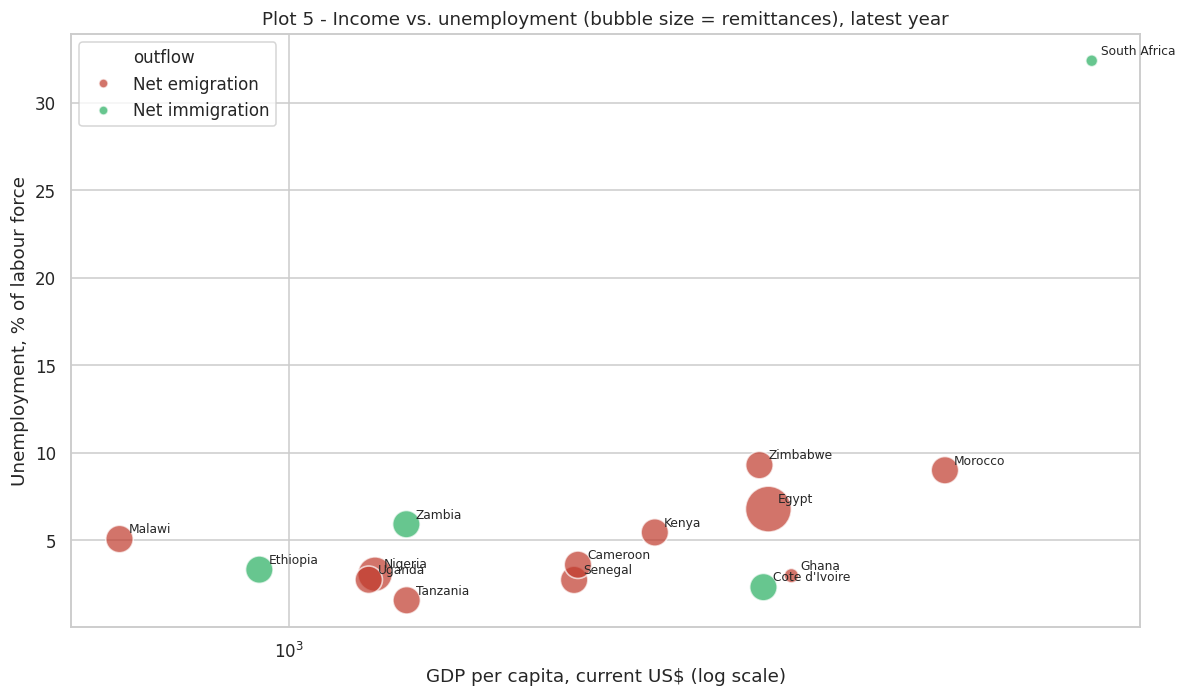

In [8]:
snap = (panel.dropna(subset=["gdp_per_capita", "unemployment"]).sort_values("year")
        .groupby("country").tail(1).copy())
snap["outflow"] = np.where(snap["net_migration"] < 0, "Net emigration", "Net immigration")
snap["size"] = snap["remittances_usd"].fillna(snap["remittances_usd"].median()) / 1e8

fig, ax = plt.subplots(figsize=(11, 6.5))
sns.scatterplot(data=snap, x="gdp_per_capita", y="unemployment", hue="outflow",
                size="size", sizes=(60, 900), palette={"Net emigration": "#c0392b",
                "Net immigration": "#27ae60"}, alpha=0.7, ax=ax, legend="brief")
for _, r in snap.iterrows():
    ax.annotate(r["country"], (r["gdp_per_capita"], r["unemployment"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xscale("log")
ax.set_xlabel("GDP per capita, current US$ (log scale)")
ax.set_ylabel("Unemployment, % of labour force")
ax.set_title("Plot 5 - Income vs. unemployment (bubble size = remittances), latest year")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:3], labels[:3], loc="upper left")
plt.tight_layout()
plt.show()

**Insight:** Every country in the panel has GDP per capita below US$7,000, a fraction of US
GDP per capita (well above US$80,000), so a doctor or engineer can multiply their earnings many
times over by moving to the United States. South Africa's unemployment rate (over 30%) is extreme;
most other countries show low *measured* unemployment that hides widespread informal work and
underemployment of graduates.

## 6. Net migration rate heatmap (per 1,000 residents)

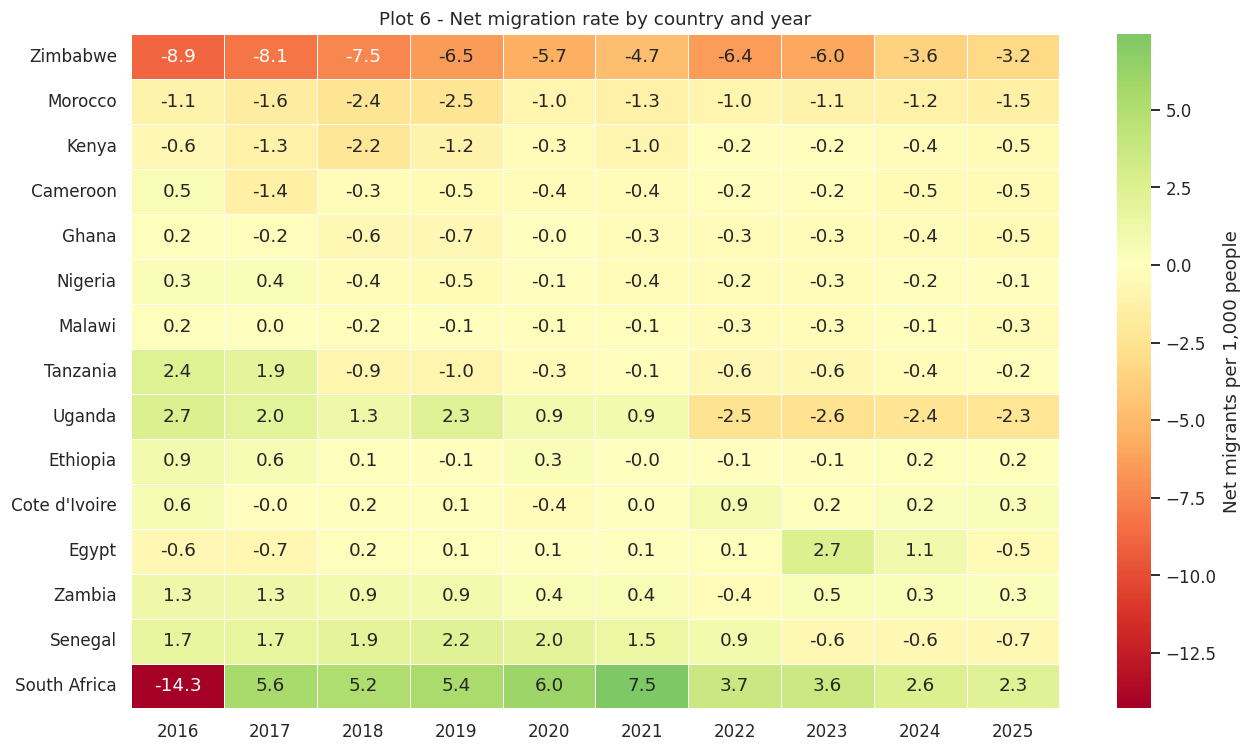

In [9]:
rate = panel.pivot(index="country", columns="year", values="net_migration_per_1000")
rate = rate.loc[rate.mean(axis=1).sort_values().index]
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(rate, cmap="RdYlGn", center=0, annot=True, fmt=".1f", linewidths=0.4,
            cbar_kws={"label": "Net migrants per 1,000 people"}, ax=ax)
ax.set_title("Plot 6 - Net migration rate by country and year")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

**Insight:** Scaled by population, Zimbabwe stands out year after year as the most severe case of
emigration, and Morocco and Uganda also lose a meaningful share of residents. Nigeria's huge
population makes its per-capita rate look small even though it is the largest African source of
skilled immigrants to the USA in absolute terms.

## 7. How the indicators relate to each other

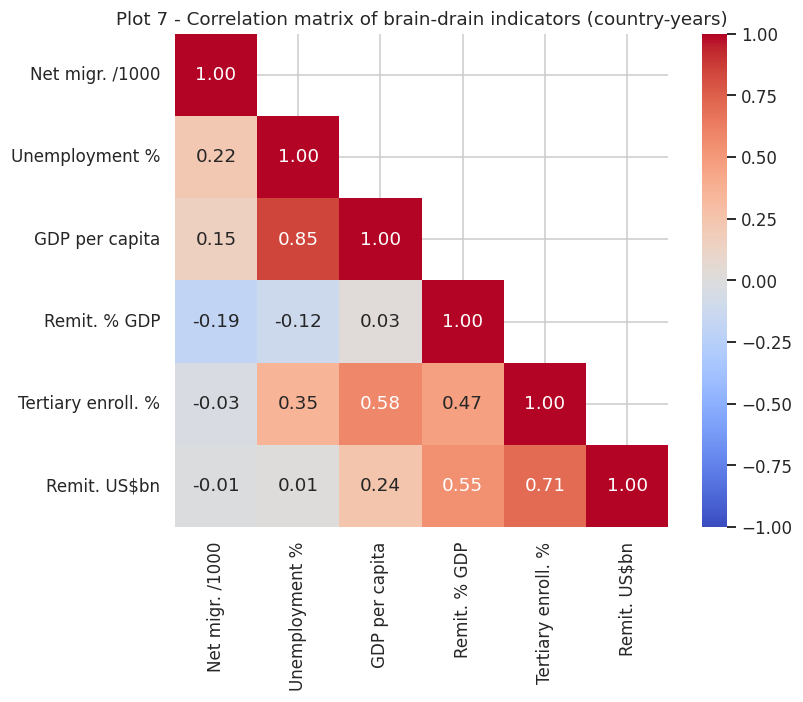

In [10]:
cols = {"net_migration_per_1000": "Net migr. /1000", "unemployment": "Unemployment %",
        "gdp_per_capita": "GDP per capita", "remittances_pct_gdp": "Remit. % GDP",
        "tertiary_enrollment": "Tertiary enroll. %", "remittances_bn": "Remit. US$bn"}
corr = panel[list(cols)].rename(columns=cols).corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, ax=ax)
ax.set_title("Plot 7 - Correlation matrix of brain-drain indicators (country-years)")
plt.tight_layout()
plt.show()

## 8. Education pipeline: training talent that leaves

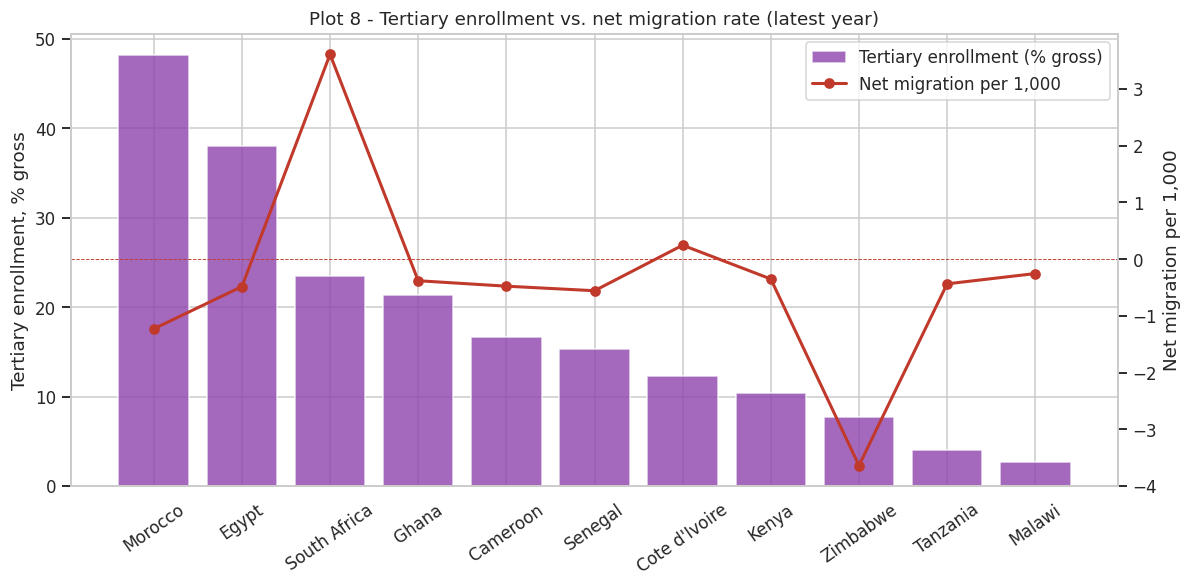

In [11]:
edu = (panel.dropna(subset=["tertiary_enrollment"]).sort_values("year")
       .groupby("country").tail(1).sort_values("tertiary_enrollment", ascending=False))
fig, ax1 = plt.subplots(figsize=(11, 5.5))
bars = ax1.bar(edu["country"], edu["tertiary_enrollment"], color="#8e44ad", alpha=0.8,
               label="Tertiary enrollment (% gross)")
ax1.set_ylabel("Tertiary enrollment, % gross")
ax1.tick_params(axis="x", rotation=35)
ax2 = ax1.twinx()
ax2.plot(edu["country"], edu["net_migration_per_1000"], color="#c0392b", marker="o",
         lw=2, label="Net migration per 1,000")
ax2.axhline(0, color="#c0392b", lw=0.6, ls="--")
ax2.set_ylabel("Net migration per 1,000")
ax2.grid(False)
lines = [bars, ax2.lines[0]]
ax1.legend(lines, [l.get_label() for l in lines], loc="upper right")
ax1.set_title("Plot 8 - Tertiary enrollment vs. net migration rate (latest year)")
plt.tight_layout()
plt.show()

**Insight:** Morocco and Egypt combine the highest tertiary enrollment in the panel with net
emigration. They train large numbers of graduates whom domestic labour markets cannot absorb,
which is the classic brain-drain profile. Zimbabwe is the exception that proves the point: modest
enrollment but the steepest outflow rate, because its trained nurses and doctors leave en masse. In
very low-enrollment countries (Tanzania, Malawi), each departing doctor is a large share of a tiny
skilled workforce.

## 9. Brain Drain Pressure Index

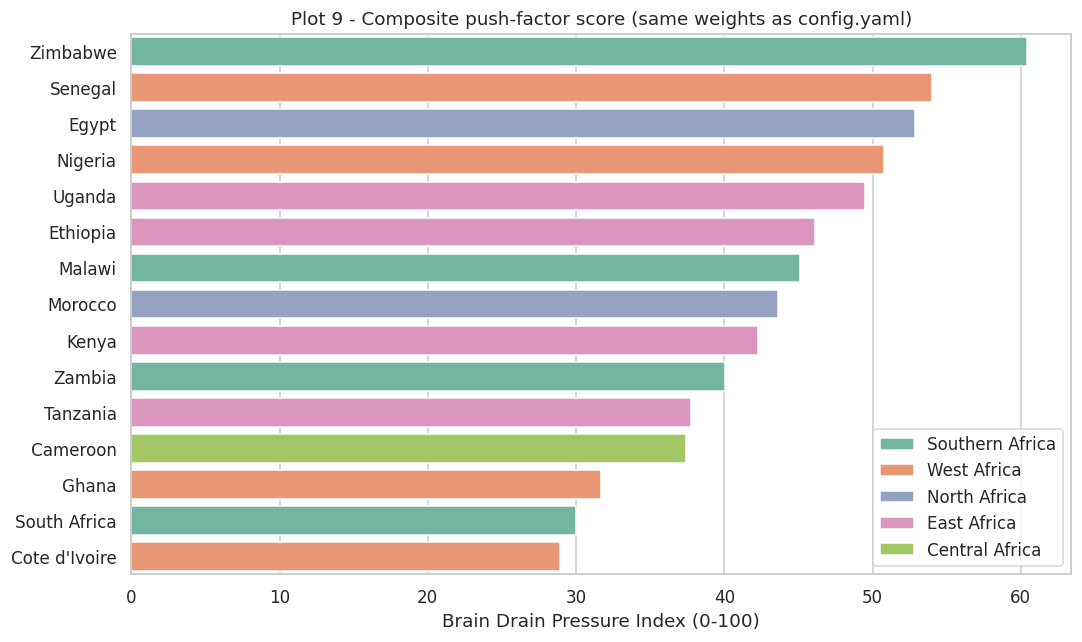

,country,region,unemployment,gdp_per_capita,net_migration_per_1000,remittances_pct_gdp,index
0,Zimbabwe,Southern Africa,9.29,"3,021.43",-3.22,8.45,60.39
5,Senegal,West Africa,2.74,"1,954.71",-0.67,10.64,54.02
12,Egypt,North Africa,6.78,"3,085.81",-0.48,11.37,52.87
1,Nigeria,West Africa,3.06,"1,224.25",-0.06,7.84,50.80
8,Uganda,East Africa,2.75,"1,206.30",-2.32,2.65,49.49
10,Ethiopia,East Africa,3.32,932.73,0.18,4.77,46.13
2,Malawi,Southern Africa,5.07,671.51,-0.25,1.65,45.13
4,Morocco,North Africa,9.00,"4,672.47",-1.46,7.49,43.60
3,Kenya,East Africa,5.45,"2,362.86",-0.48,4.15,42.24
13,Zambia,Southern Africa,5.92,"1,317.88",0.30,1.32,40.07


In [12]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

idx = snap[["country", "region", "unemployment", "gdp_per_capita"]].merge(
    panel.dropna(subset=["net_migration_per_1000"]).sort_values("year").groupby("country")
         .tail(1)[["country", "net_migration_per_1000"]], on="country", how="left").merge(
    panel.dropna(subset=["remittances_pct_gdp"]).sort_values("year").groupby("country")
         .tail(1)[["country", "remittances_pct_gdp"]], on="country", how="left")
idx["index"] = 100 * (0.30 * minmax(idx["unemployment"])
                      + 0.30 * (1 - minmax(idx["gdp_per_capita"]))
                      + 0.20 * (1 - minmax(idx["net_migration_per_1000"]))
                      + 0.20 * minmax(idx["remittances_pct_gdp"])).fillna(0.5)
idx = idx.sort_values("index", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=idx, y="country", x="index", hue="region", dodge=False, ax=ax,
            palette="Set2")
ax.set_xlabel("Brain Drain Pressure Index (0-100)")
ax.set_ylabel("")
ax.set_title("Plot 9 - Composite push-factor score (same weights as config.yaml)")
ax.legend(title="", loc="lower right")
plt.tight_layout()
plt.show()
idx.round(2)

## 10. Key takeaways

1. **Net emigration is concentrated in a few countries.** Zimbabwe, Morocco, Kenya and Nigeria
   account for most of the panel's net outflow in 2016-2025. South Africa is a net receiver at
   regional level, but it still loses its own skilled professionals overseas.
2. **The diaspora pays back.** Remittances to these 15 countries grew by more than 50%
   (US$57bn to US$89bn between 2016 and 2024). For Egypt,
   Senegal and Zimbabwe, remittances equal roughly 8-11% of GDP.
3. **The income gap is the main pull.** With GDP per capita between about US$670 (Malawi) and
   US$6,600 (South Africa), versus well over US$80,000 in the USA, the income gap is
   roughly 13x to more than 100x, a powerful pull for doctors, nurses and engineers.
4. **Education without absorption fuels emigration.** High-enrollment countries with net outflows
   (Morocco, Egypt) show the pattern of producing graduates for foreign labour markets.
5. **The Brain Drain Pressure Index** ranks Zimbabwe, Senegal, Egypt and Nigeria as the highest
   pressure countries. These are natural priorities for retention policies (health-worker
   bonding, diaspora investment bonds, tech-hub incentives).

*Next steps:* join US-side data (DHS Yearbook of Immigration Statistics, ACS foreign-born by
education) to isolate the skilled, USA-bound part of these flows.